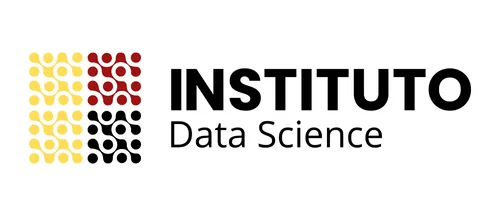 https://institutodatascience.org/


In [ ]:
# getting the dataset in
!wget https://download.pytorch.org/tutorial/hymenoptera_data.zip

# unzipping the dataset
!unzip hymenoptera_data.zip

--2024-08-08 19:00:44--  https://download.pytorch.org/tutorial/hymenoptera_data.zip
Resolving download.pytorch.org (download.pytorch.org)... 18.238.238.104, 18.238.238.23, 18.238.238.114, ...
Connecting to download.pytorch.org (download.pytorch.org)|18.238.238.104|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 47286322 (45M) [application/zip]
Saving to: ‘hymenoptera_data.zip’

hymenoptera_data.zi 100%[===================>]  45.10M  80.0MB/s    in 0.6s    

2024-08-08 19:00:45 (80.0 MB/s) - ‘hymenoptera_data.zip’ saved [47286322/47286322]

Archive:  hymenoptera_data.zip
   creating: hymenoptera_data/
   creating: hymenoptera_data/train/
   creating: hymenoptera_data/train/ants/
  inflating: hymenoptera_data/train/ants/0013035.jpg  
  inflating: hymenoptera_data/train/ants/1030023514_aad5c608f9.jpg  
  inflating: hymenoptera_data/train/ants/1095476100_3906d8afde.jpg  
  inflating: hymenoptera_data/train/ants/1099452230_d1949d3250.jpg  
  inflating: hymenoptera_

In [ ]:
%matplotlib inline

Transfer Learning para DL / VC
==============================================

En este tutorial, aprenderás cómo entrenar una red neuronal convolucional para la clasificación de imágenes utilizando transfer learning. Puedes leer más sobre el transfer learning en las `notas de cs231n <https://cs231n.github.io/transfer-learning/>`__.

Citando estas notas,

    En la práctica, muy pocas personas entrenan una Red Convolucional
    completa desde cero (con inicialización aleatoria), porque es relativamente
    raro tener un conjunto de datos de tamaño suficiente. En cambio, es común
    preentrenar una ConvNet en un conjunto de datos muy grande (por ejemplo, ImageNet, que
    contiene 1.2 millones de imágenes con 1000 categorías), y luego usar la
    ConvNet ya sea como inicialización o como extractor de características fijo para
    la tarea de interés.

Estos dos escenarios principales de transfer learning se ven de la siguiente manera:

-  **Ajuste fino de la convnet**: En lugar de inicialización aleatoria, nosotros
   inicializamos la red con una red preentrenada, como la que está
   entrenada en el conjunto de datos imagenet 1000. El resto del entrenamiento se ve
   como de costumbre.
-  **ConvNet como extractor de características fijo**: Aquí, congelaremos los pesos
   para toda la red excepto los de la capa completamente conectada final.
   Esta última capa completamente conectada se reemplaza con una nueva
   con pesos aleatorios y solo se entrena esta capa.


In [ ]:
# License: BSD
# Author: Sasank Chilamkurthy

from __future__ import print_function, division

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import numpy as np
import torchvision
from torchvision import datasets, models, transforms
import matplotlib.pyplot as plt
import time
import os
import copy

plt.ion()   # interactive mode

Cargar Datos
---------

Utilizaremos los paquetes torchvision y torch.utils.data para cargar los datos.

El problema que resolveremos hoy es entrenar un modelo para clasificar **hormigas** y **abejas**. Tenemos alrededor de 120 imágenes de entrenamiento para cada clase, hormigas y abejas. Hay 75 imágenes de validación para cada clase. Por lo general, este es un conjunto de datos muy pequeño para generalizar, si se entrena desde cero. Dado que estamos utilizando transfer learning, deberíamos poder generalizar razonablemente bien.

Este conjunto de datos es un subconjunto muy pequeño de ImageNet.

.. Nota ::
   Descarga los datos desde
   `aquí <https://download.pytorch.org/tutorial/hymenoptera_data.zip>`_
   y extráelos al directorio actual.


#### Cargar aquí su dirección donde salvó los datos
Se debe suministrar la ruta de la carpeta "hymenoptera_data". El programa busca las carpetas `train` y `val` automáticamente.

In [ ]:
data_dir = '/content/hymenoptera_data'

In [ ]:
# Data augmentation and normalization for training
# Just normalization for validation

# Se definen las transformaciones de datos para el conjunto de entrenamiento y validación
data_transforms = {
    'train': transforms.Compose([
        # Para el conjunto de entrenamiento:
        transforms.RandomResizedCrop(224),    # Recorte aleatorio y redimensionamiento a 224x224 píxeles
        transforms.RandomHorizontalFlip(),    # Volteo horizontal aleatorio
        transforms.ToTensor(),                # Conversión de la imagen a tensor
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])   # Normalización de los canales RGB
    ]),
    'val': transforms.Compose([
        # Para el conjunto de validación:
        transforms.Resize(256),               # Redimensionamiento a 256x256 píxeles
        transforms.CenterCrop(224),           # Recorte centrado a 224x224 píxeles
        transforms.ToTensor(),                # Conversión de la imagen a tensor
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])   # Normalización de los canales RGB
    ]),
}

# Se crean conjuntos de datos utilizando las transformaciones definidas
image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x),
                                          data_transforms[x])
                  for x in ['train', 'val']}

# Se crean cargadores de datos para iterar sobre los conjuntos de datos en lotes
dataloaders = {x: torch.utils.data.DataLoader(image_datasets[x], batch_size=4,
                                             shuffle=True, num_workers=4)
              for x in ['train', 'val']}

# Se obtienen los tamaños de los conjuntos de datos
dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val']}

# Se obtienen los nombres de las clases
class_names = image_datasets['train'].classes

# Se define el dispositivo de cómputo a utilizar (CPU o GPU)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")


**Visualicemos algunas imágenes de entrenamiento para comprender las transformaciones de datos.**


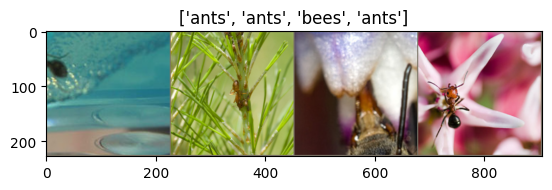

In [ ]:
def imshow(inp, title=None):
    """Imshow for Tensor."""
    # Convertir el tensor de imagen a un arreglo NumPy y cambiar el orden de los ejes para que sea (altura, ancho, canales)
    inp = inp.numpy().transpose((1, 2, 0))

    # Definir la media y la desviación estándar para normalizar la imagen
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    # Desnormalizar la imagen (invertir la normalización)
    inp = std * inp + mean

    # Asegurar que los valores de píxeles estén en el rango [0, 1]
    inp = np.clip(inp, 0, 1)

    # Mostrar la imagen utilizando matplotlib
    plt.imshow(inp)

    # Añadir un título a la imagen si se proporciona
    if title is not None:
        plt.title(title)

    # Pausa breve para que se actualicen los gráficos
    plt.pause(0.001)


# Obtener un lote de datos de entrenamiento
inputs, classes = next(iter(dataloaders['train']))

# Crear una cuadrícula de imágenes a partir del lote
out = torchvision.utils.make_grid(inputs)

# Llamar a la función imshow para visualizar el lote de imágenes junto con sus etiquetas de clase correspondientes
imshow(out, title=[class_names[x] for x in classes])


Training the model
------------------

Now, let's write a general function to train a model. Here, we will
illustrate:

-  Scheduling the learning rate
-  Saving the best model

In the following, parameter ``scheduler`` is an LR scheduler object from
``torch.optim.lr_scheduler``.



In [ ]:
def train_model(model, criterion, optimizer, scheduler, num_epochs=25):
    """
    Función para entrenar un modelo.

    Parámetros:
        - model: modelo a entrenar.
        - criterion: función de pérdida.
        - optimizer: optimizador para actualizar los pesos del modelo.
        - scheduler: programador de la tasa de aprendizaje.
        - num_epochs: número de épocas de entrenamiento (por defecto, 25).
    """
    since = time.time()  # Registrar el tiempo de inicio del entrenamiento

    best_model_wts = copy.deepcopy(model.state_dict())  # Copiar los mejores pesos del modelo
    best_acc = 0.0  # Inicializar la mejor precisión como 0

    for epoch in range(num_epochs):  # Iterar sobre el número de épocas
        print('Epoch {}/{}'.format(epoch, num_epochs - 1))  # Imprimir el número de época
        print('-' * 10)  # Imprimir una línea divisoria

        # Iterar sobre las fases de entrenamiento y validación
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()  # Poner el modelo en modo de entrenamiento
            else:
                model.eval()   # Poner el modelo en modo de evaluación

            running_loss = 0.0  # Inicializar la pérdida acumulada en cero
            running_corrects = 0  # Inicializar el número de predicciones correctas en cero

            # Iterar sobre los datos
            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)  # Mover los datos a la GPU si está disponible
                labels = labels.to(device)  # Mover las etiquetas a la GPU si está disponible

                optimizer.zero_grad()  # Reiniciar los gradientes acumulados en cero

                # Propagación hacia adelante
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)  # Calcular las salidas del modelo
                    _, preds = torch.max(outputs, 1)  # Obtener las predicciones
                    loss = criterion(outputs, labels)  # Calcular la pérdida

                    # Retropropagación y actualización de parámetros solo si está en fase de entrenamiento
                    if phase == 'train':
                        loss.backward()  # Retropropagación
                        optimizer.step()  # Actualizar los parámetros

                # Calcular estadísticas
                running_loss += loss.item() * inputs.size(0)  # Acumular la pérdida total
                running_corrects += torch.sum(preds == labels.data)  # Contar las predicciones correctas

            if phase == 'train':
                scheduler.step()  # Programar el paso de la tasa de aprendizaje

            # Calcular la pérdida y la precisión por época
            epoch_loss = running_loss / dataset_sizes[phase]  # Pérdida promedio por época
            epoch_acc = running_corrects.double() / dataset_sizes[phase]  # Precisión promedio por época

            # Imprimir la pérdida y la precisión
            print('{} Loss: {:.4f} Acc: {:.4f}'.format(
                phase, epoch_loss, epoch_acc))

            # Guardar los mejores pesos del modelo si la precisión de validación mejora
            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())

        print()  # Imprimir línea en blanco para separar las épocas

    time_elapsed = time.time() - since  # Calcular el tiempo transcurrido durante el entrenamiento
    print('Training complete in {:.0f}m {:.0f}s'.format(
        time_elapsed // 60, time_elapsed % 60))  # Imprimir el tiempo transcurrido
    print('Best val Acc: {:4f}'.format(best_acc))  # Imprimir la mejor precisión de validación obtenida

    # Cargar los mejores pesos del modelo
    model.load_state_dict(best_model_wts)
    return model  # Devolver el modelo entrenado con los mejores pesos


Visualizing the model predictions
^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

Generic function to display predictions for a few images




In [ ]:
def visualize_model(model, num_images=6):
    """
    Función para visualizar las predicciones del modelo en un conjunto de datos de validación.

    Parámetros:
        - model: modelo entrenado.
        - num_images: número de imágenes a visualizar (por defecto, 6).
    """
    was_training = model.training  # Registrar si el modelo estaba en modo de entrenamiento
    model.eval()  # Poner el modelo en modo de evaluación
    images_so_far = 0  # Contador de imágenes procesadas

    # Crear una figura para visualizar las imágenes
    fig = plt.figure()

    with torch.no_grad():  # Desactivar el cálculo de gradientes
        for i, (inputs, labels) in enumerate(dataloaders['val']):
            inputs = inputs.to(device)  # Mover los datos a la GPU si está disponible
            labels = labels.to(device)  # Mover las etiquetas a la GPU si está disponible

            outputs = model(inputs)  # Calcular las salidas del modelo
            _, preds = torch.max(outputs, 1)  # Obtener las predicciones

            # Iterar sobre las imágenes en el lote
            for j in range(inputs.size()[0]):
                images_so_far += 1  # Incrementar el contador de imágenes
                ax = plt.subplot(num_images // 2, 2, images_so_far)  # Crear un subgráfico
                ax.axis('off')  # Desactivar los ejes
                ax.set_title('predicted: {}'.format(class_names[preds[j]]))  # Establecer el título del subgráfico
                imshow(inputs.cpu().data[j])  # Mostrar la imagen

                # Si se ha alcanzado el número máximo de imágenes a visualizar, volver al modo de entrenamiento y salir del bucle
                if images_so_far == num_images:
                    model.train(mode=was_training)  # Volver al modo de entrenamiento
                    return

    model.train(mode=was_training)  # Volver al modo de entrenamiento si no se han visualizado todas las imágenes



##Ajuste fino de la convnet

Cargar un modelo preentrenado y restablecer la capa completamente conectada final.








In [ ]:
model_ft = models.resnet18(pretrained=True)  # Cargar un modelo ResNet-18 preentrenado
num_ftrs = model_ft.fc.in_features  # Obtener el número de características de entrada de la última capa completamente conectada

# Aquí, el tamaño de cada muestra de salida se establece en 2.
# Alternativamente, se puede generalizar a nn.Linear(num_ftrs, len(class_names)).
model_ft.fc = nn.Linear(num_ftrs, 2)  # Reemplazar la última capa completamente conectada con una nueva capa lineal

model_ft = model_ft.to(device)  # Mover el modelo a la GPU si está disponible

criterion = nn.CrossEntropyLoss()  # Definir la función de pérdida como la pérdida de entropía cruzada

# Observar que se optimizan todos los parámetros
optimizer_ft = optim.SGD(model_ft.parameters(), lr=0.001, momentum=0.9)  # Definir el optimizador SGD con momento

# Decaimiento de la tasa de aprendizaje por un factor de 0.1 cada 7 épocas
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_ft, step_size=7, gamma=0.1)  # Programar el decaimiento de la tasa de aprendizaje


/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 64.8MB/s]


Train and evaluate
^^^^^^^^^^^^^^^^^^

It should take around 15-25 min on CPU. On GPU though, it takes less than a
minute.




In [ ]:
model_ft = train_model(model_ft, criterion, optimizer_ft, exp_lr_scheduler,
                       num_epochs=7)

Epoch 0/6
----------
train Loss: 0.5479 Acc: 0.6967
val Loss: 0.2602 Acc: 0.9216

Epoch 1/6
----------
train Loss: 0.6200 Acc: 0.7582
val Loss: 0.3881 Acc: 0.8562

Epoch 2/6
----------
train Loss: 0.4301 Acc: 0.8238
val Loss: 0.4937 Acc: 0.8301

Epoch 3/6
----------
train Loss: 0.4881 Acc: 0.8074
val Loss: 0.4805 Acc: 0.7908

Epoch 4/6
----------
train Loss: 0.6329 Acc: 0.7500
val Loss: 0.3363 Acc: 0.8562

Epoch 5/6
----------
train Loss: 0.3356 Acc: 0.8443
val Loss: 0.2072 Acc: 0.9150

Epoch 6/6
----------
train Loss: 0.5114 Acc: 0.7951
val Loss: 0.3118 Acc: 0.8954

Training complete in 0m 24s
Best val Acc: 0.921569


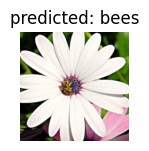

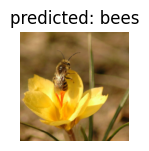

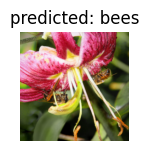

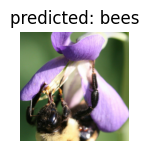

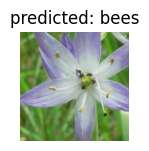

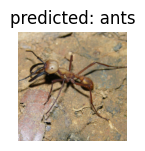

In [ ]:
visualize_model(model_ft)

ConvNet como extractor de características fijas
----------------------------------

Aquí, necesitamos congelar toda la red excepto la capa final. Necesitamos
establecer ``requires_grad = False`` para congelar los parámetros de modo que los
gradientes no se calculen en ``backward()``.

Puedes leer más sobre esto en la documentación
`aquí <https://pytorch.org/docs/notes/autograd.html#excluding-subgraphs-from-backward>`__.


In [ ]:
model_conv = torchvision.models.resnet18(pretrained=True)  # Cargar un modelo ResNet-18 preentrenado

# Congelar los parámetros de todas las capas de la red
for param in model_conv.parameters():
    param.requires_grad = False

# Crear una nueva capa lineal para la clasificación binaria (dos clases)
num_ftrs = model_conv.fc.in_features
model_conv.fc = nn.Linear(num_ftrs, 2)

model_conv = model_conv.to(device)  # Mover el modelo a la GPU si está disponible

criterion = nn.CrossEntropyLoss()  # Definir la función de pérdida como la pérdida de entropía cruzada

# Observar que solo se optimizan los parámetros de la capa final, no de toda la red
optimizer_conv = optim.SGD(model_conv.fc.parameters(), lr=0.001, momentum=0.9)  # Definir el optimizador SGD con momento

# Decaimiento de la tasa de aprendizaje por un factor de 0.1 cada 7 épocas
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_conv, step_size=7, gamma=0.1)  # Programar el decaimiento de la tasa de aprendizaje


Entrenamiento y evaluación
^^^^^^^^^^^^^^^^^^

En CPU, esto tomará aproximadamente la mitad del tiempo en comparación con el escenario anterior. Esto es esperado ya que no es necesario calcular los gradientes para la mayor parte de la red. Sin embargo, sí es necesario calcular la propagación hacia adelante.



In [ ]:
model_conv = train_model(model_conv, criterion, optimizer_conv,
                         exp_lr_scheduler, num_epochs=7)

Epoch 0/6
----------
train Loss: 0.5654 Acc: 0.6885
val Loss: 0.2541 Acc: 0.8954

Epoch 1/6
----------
train Loss: 0.4590 Acc: 0.8033
val Loss: 0.1816 Acc: 0.9346

Epoch 2/6
----------
train Loss: 0.5908 Acc: 0.7459
val Loss: 0.5478 Acc: 0.7843

Epoch 3/6
----------
train Loss: 0.4972 Acc: 0.7951
val Loss: 0.2021 Acc: 0.9150

Epoch 4/6
----------
train Loss: 0.5953 Acc: 0.7500
val Loss: 0.3571 Acc: 0.8562

Epoch 5/6
----------
train Loss: 0.3698 Acc: 0.8402
val Loss: 0.1860 Acc: 0.9477

Epoch 6/6
----------
train Loss: 0.5992 Acc: 0.7459
val Loss: 0.1769 Acc: 0.9477

Training complete in 0m 31s
Best val Acc: 0.947712


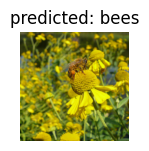

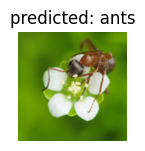

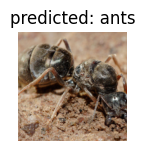

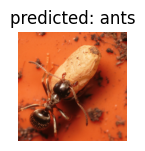

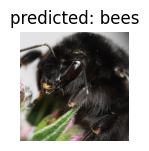

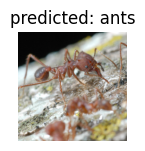

In [ ]:
visualize_model(model_conv)

plt.ioff()
plt.show()

Further Learning
-----------------

If you would like to learn more about the applications of transfer learning,
checkout our `Quantized Transfer Learning for Computer Vision Tutorial <https://pytorch.org/tutorials/intermediate/quantized_transfer_learning_tutorial.html>`_.



